<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Another-classification-example:-cancer-survival-data" data-toc-modified-id="Another-classification-example:-cancer-survival-data-1"><span class="toc-item-num">1&nbsp;&nbsp;</span><font color="red">Another classification example: cancer survival data</font></a></span></li><li><span><a href="#EDA:-let's-inspect-the-data!" data-toc-modified-id="EDA:-let's-inspect-the-data!-2"><span class="toc-item-num">2&nbsp;&nbsp;</span><font color="red">EDA: let's inspect the data!</font></a></span></li><li><span><a href="#Fit-a-k-NN-classifier" data-toc-modified-id="Fit-a-k-NN-classifier-3"><span class="toc-item-num">3&nbsp;&nbsp;</span><font color="red">Fit a k-NN classifier</font></a></span><ul class="toc-item"><li><span><a href="#Utility-functions-(already-defined-in-previous-notebooks)" data-toc-modified-id="Utility-functions-(already-defined-in-previous-notebooks)-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span><font color="red">Utility functions (already defined in previous notebooks)</font></a></span></li><li><span><a href="#Use-the-two-relevant-features" data-toc-modified-id="Use-the-two-relevant-features-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span><font color="red">Use the two relevant features</font></a></span></li></ul></li><li><span><a href="#Model-selection:-use-Hold-Out-/-Cross-Validation-to-select-the-best-model" data-toc-modified-id="Model-selection:-use-Hold-Out-/-Cross-Validation-to-select-the-best-model-4"><span class="toc-item-num">4&nbsp;&nbsp;</span><font color="red">Model selection: use Hold-Out / Cross-Validation to select the <strong>best model</strong></font></a></span></li><li><span><a href="#Automatic-grid-search-for-model-selection-(i.e.,-best-$k$)" data-toc-modified-id="Automatic-grid-search-for-model-selection-(i.e.,-best-$k$)-5"><span class="toc-item-num">5&nbsp;&nbsp;</span><font color="red">Automatic grid search for model selection (i.e., best $k$)</font></a></span></li><li><span><a href="#k-NN-and-role-of-distances" data-toc-modified-id="k-NN-and-role-of-distances-6"><span class="toc-item-num">6&nbsp;&nbsp;</span><font color="red">k-NN and role of distances</font></a></span><ul class="toc-item"><li><span><a href="#Minkowski-distance?" data-toc-modified-id="Minkowski-distance?-6.1"><span class="toc-item-num">6.1&nbsp;&nbsp;</span><font color="red">Minkowski distance?</font></a></span></li><li><span><a href="#$L_p$-norm-and-distances" data-toc-modified-id="$L_p$-norm-and-distances-6.2"><span class="toc-item-num">6.2&nbsp;&nbsp;</span><font color="red">$L_p$-norm and distances</font></a></span></li></ul></li><li><span><a href="#Measures-of-performance-for-classification:-Accuracy,-Recall,-Precision,-F1,-Confusion-Matrix" data-toc-modified-id="Measures-of-performance-for-classification:-Accuracy,-Recall,-Precision,-F1,-Confusion-Matrix-7"><span class="toc-item-num">7&nbsp;&nbsp;</span><font color="red">Measures of performance for classification: Accuracy, Recall, Precision, F1, Confusion Matrix</font></a></span><ul class="toc-item"><li><span><a href="#Full-report-on-classification-performance-and-F1-metric" data-toc-modified-id="Full-report-on-classification-performance-and-F1-metric-7.1"><span class="toc-item-num">7.1&nbsp;&nbsp;</span><font color="red">Full report on classification performance and F1 metric</font></a></span></li><li><span><a href="#Confusion-matrix--(to-check-cross-missclassifications)" data-toc-modified-id="Confusion-matrix--(to-check-cross-missclassifications)-7.2"><span class="toc-item-num">7.2&nbsp;&nbsp;</span><font color="red"><b>Confusion matrix</b>  (to check cross-missclassifications)</font></a></span></li></ul></li></ul></div>

***
<span style="color:#008385">

**15-288: Machine Learning in a Nutshell**, *CMU-Qatar* Spring'26

**Gianni A. Di Caro**, www.giannidicaro.com

<u>Disclaimer:</u> This notebook was prepared for teaching purposes. It can include material from different web sources. I'll be happy to explicitly acknowledge a source if required. 
</span>
***

***
# <font color='red'>Another classification example: cancer survival data</font>

In this case, we have a <font color='blue'>CSV file</font> to read. We can use Pandas to read, inspect, and manipulate file data.

The dataset contains data collected in about 30 years (from the '50s) in Chicago hospitals, about the <font color='red'>survival rate of women with a diagnosis of breast cancer after a surgical operation to remove the cancer.</font> 

***
<font color='blue'>**Features**:</font>

Data consists of records of three numeric features:
- age 
- year of operation
- number of axillary nodes (lymph nodes) before the operation. 

***
<font color='blue'>**Labels (binary)**:</font>

- 1: survival after 5 years from the operation
- 2: death within 5 years from the operation.
***

Let's read the data from the CSV file

In [22]:
import pandas as pd

In [23]:
cancer = pd.read_csv('datasets/haberman_breast_cancer.csv') 

In [24]:
cancer

,age,year of operation,axillary nodes,survival (1-survived > 5y; 2-died in <5 y)
0,30,64,1,1
1,30,62,3,1
2,30,65,0,1
3,31,59,2,1
4,31,65,4,1
...,...,...,...,...
301,75,62,1,1
302,76,67,0,1
303,77,65,3,1
304,78,65,1,2


***
For convenience, let's store feature data `age` and `axillary nodes` (that seem to be the only meaningful predictors) and targets in named arrays

In [25]:
age = cancer['age']
nodes = cancer['axillary nodes']
targets = cancer.iloc[:, -1]

***
# <font color='red'>EDA: let's inspect the data!</font>

In [26]:
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.dpi']= 130

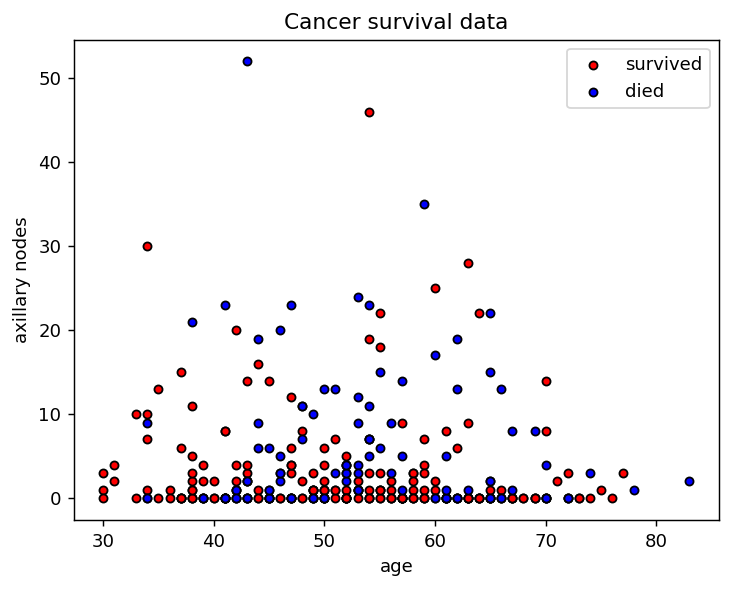

In [27]:
plt.figure()
plt.xlabel('age')
plt.ylabel('axillary nodes')

labels = ['survived', 'died']
colors = ['r', 'b']

# plot the training points
for t in [1,2]:
    plt.scatter(age[targets == t], 
                nodes[targets == t],
                color=colors[t-1],  
                edgecolor='black', 
                label=labels[t-1],
                s=20)
plt.legend()
plt.title('Cancer survival data')

plt.show()

<font color='red'>Data seems quite messy, hard to separate! :(</font>

***
# <font color='red'>Fit a k-NN classifier</font>

- Fit a k-NN classifier using different values for `k`, in the same way we have proceeded in the case of Iris data
    - `k = [1,2,3,4,5,6,7,8,9,20,50]`

The same functions defined before are going to be used, and are re-defined here. In this case we use the data arrays directly, as we did before for the Iris data

***
## <font color='red'>Utility functions (already defined in previous notebooks)</font>

In [28]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics 

In [29]:
def learn_kNN_classifier(features_data, targets, neighbors, voting):
    '''Set up a K-NN classifier and fits it to the given training data.
       Return: learned classifier.''' 
    
    classifier = KNeighborsClassifier(n_neighbors=neighbors, 
                                      weights=voting)
    classifier.fit(features_data, targets)
    
    return classifier

In [30]:
def get_predictions(test_features, test_targets, classifier):
    '''Input: trained classifier, test set for feature data paired with target values.
       Return: prediction labels and the mean accuracy over the test set.'''
    
    target_predictions = classifier.predict(test_features)
    
    accuracy = metrics.accuracy_score(test_targets, target_predictions)
    
    return (target_predictions, accuracy)

In [31]:
# These create some  custom color maps to try out!
from matplotlib.colors import ListedColormap
cmap_light = ListedColormap(['orange', 'cyan', 'cornflowerblue'])
cmap_bold = ListedColormap(['darkorange', 'c', 'blue'])
cmap_clear = ListedColormap(['orange', 'lightgray', 'lime'])

In [32]:
import pandas

def plot_decision_regions(X, Y, estimator, 
                          title='', x1_name='', x2_name='', 
                          legend_labels = [], meshgrid_pts = 700,
                          my_cmap='viridis', size=(14,8), data=True, s=40):
    '''Input: 
        - X has shape (number_of_training_examples, 2), i.e., two features data;
            X can be passed both as an np.array or as a pandas.DataFrame
        - Y is an array of labels for the training examples
        - title is the title of the plot
        - x1_name and x2_name are the labels of the x- and y-axis in the plot
        - legend_labels is a list if strings for the legend
        - meshgrid_pts is the number of points used for the grid, the higher
                       the more precise but the longer to make the plot
        - my_cmap sets the color map 
        - size is the size of x and y of the figure plot
        - data, if set to True will show in the plot also the training data
        - s is the size used to display training points
    '''
    
    # get feature ranges for creating a meshgrid
    # note: if X is passed as a data frame, it is first transformed to a np.array
    if type(X) == pandas.core.frame.DataFrame:
        X = X.values
    feature_ranges = np.array([ (np.floor(np.min(X[:, i])), 
                                 np.ceil(np.max(X[:, i]))) 
                                 for i in range(2)]  )
    
    # A meshgrid of values for the two selected features these are the    
    # points where the algorithm will be queried and that want to visualize.
    # Reduce the number of meshgrid_pts for a faster computation
    xx, yy = np.meshgrid( np.linspace(feature_ranges[0, 0], 
                                      feature_ranges[0, 1], 
                                      num=meshgrid_pts),
                          np.linspace(feature_ranges[1, 0],
                                      feature_ranges[1, 1], 
                                      num=meshgrid_pts))
    #print(xx.shape, yy.shape)

    # get the labels of all the points in the meshgrid
    labels_mesh = estimator.predict(np.c_[xx.ravel(), yy.ravel()])

    # reshape the array to be of the same dimesion as xx and yy
    labels_mesh = labels_mesh.reshape(xx.shape)

    #print(np.c_[xx.ravel(), yy.ravel()].shape, labels_mesh.shape)

    plt.figure(figsize=size)
    plt.title(title)

    # the color map automatically assigns a different color to the 
    # different values of labels / cluster 
    plt.pcolormesh(xx, yy, labels_mesh, cmap=my_cmap)

    # Add the original data points 
    if data == True:
        scatter= plt.scatter(X[:, 0], X[:, 1], c=Y,
                             s=s, edgecolor='black', cmap=my_cmap)

    # Add legends, it's a bit tricky to make it array-like
    if legend_labels == []:  # legends will be the same as class target values
        plt.legend(*scatter.legend_elements(),
                   loc="upper right", title="Classes")
    else:  # custom legends
        plt.legend([*scatter.legend_elements()[0]],
                   legend_labels,
                   loc="upper right", title="Classes")
               
    plt.xlabel(x1_name)
    plt.ylabel(x2_name)
    
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
        
    plt.show()

In [33]:
# import warnings filter
from warnings import simplefilter
# ignore all future warnings
simplefilter(action='ignore', category=FutureWarning)

***

## <font color='red'>Use the two relevant features</font>

Let's define the basic settings and use the utility functions fo train the k-NN classifier over a range of k values.

Only **age** and **axillary nodes** seem meaningful, so let's work with them only!

In [34]:
selected_features = [ 0, 2 ]  # 

feature_names = [ cancer.columns[selected_features[0]],
                  cancer.columns[selected_features[1]] ]

training_features_data = cancer[ feature_names ]
targets = cancer.iloc[:, -1]

voting = 'uniform'


Mean accuracy for k=1 using (age, axillary nodes): 0.853


/Users/gdicaro/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


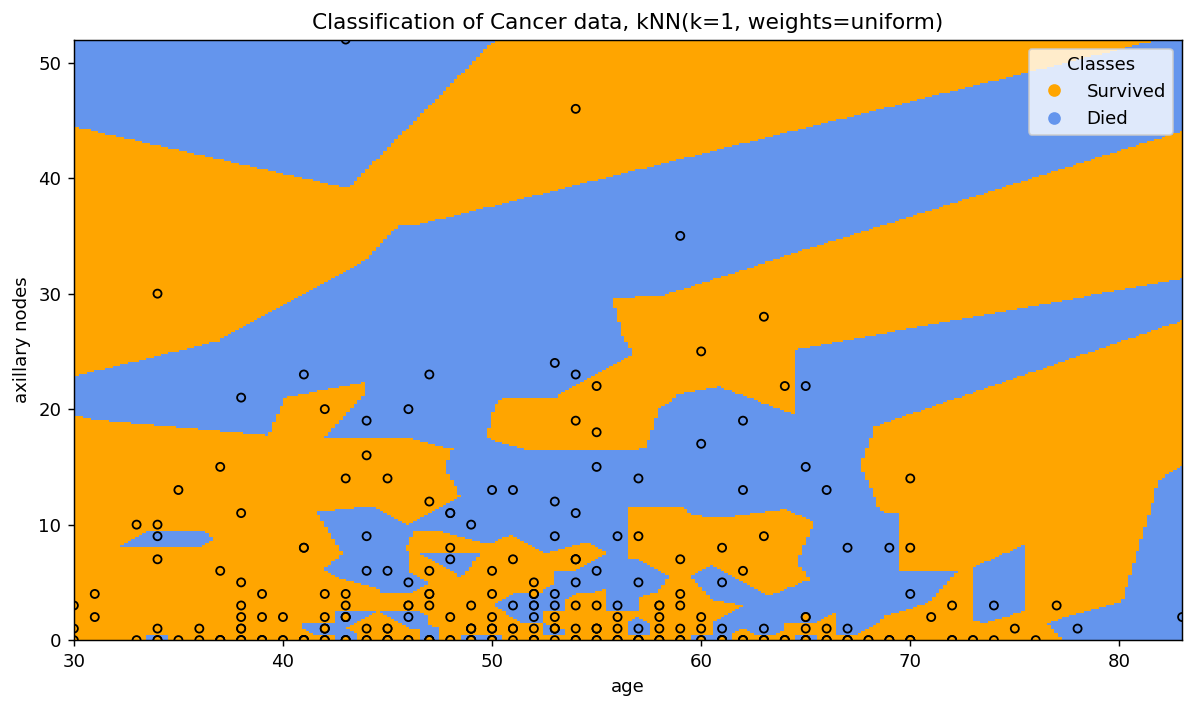


Mean accuracy for k=2 using (age, axillary nodes): 0.837


/Users/gdicaro/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


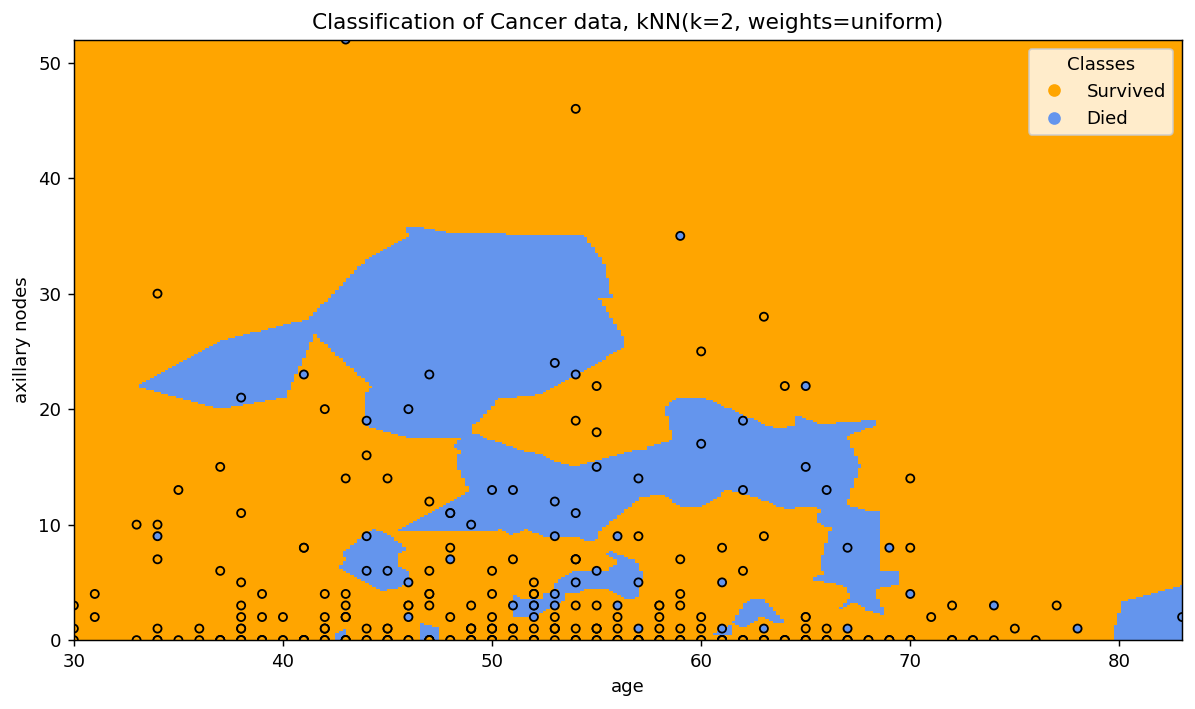


Mean accuracy for k=3 using (age, axillary nodes): 0.830


/Users/gdicaro/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


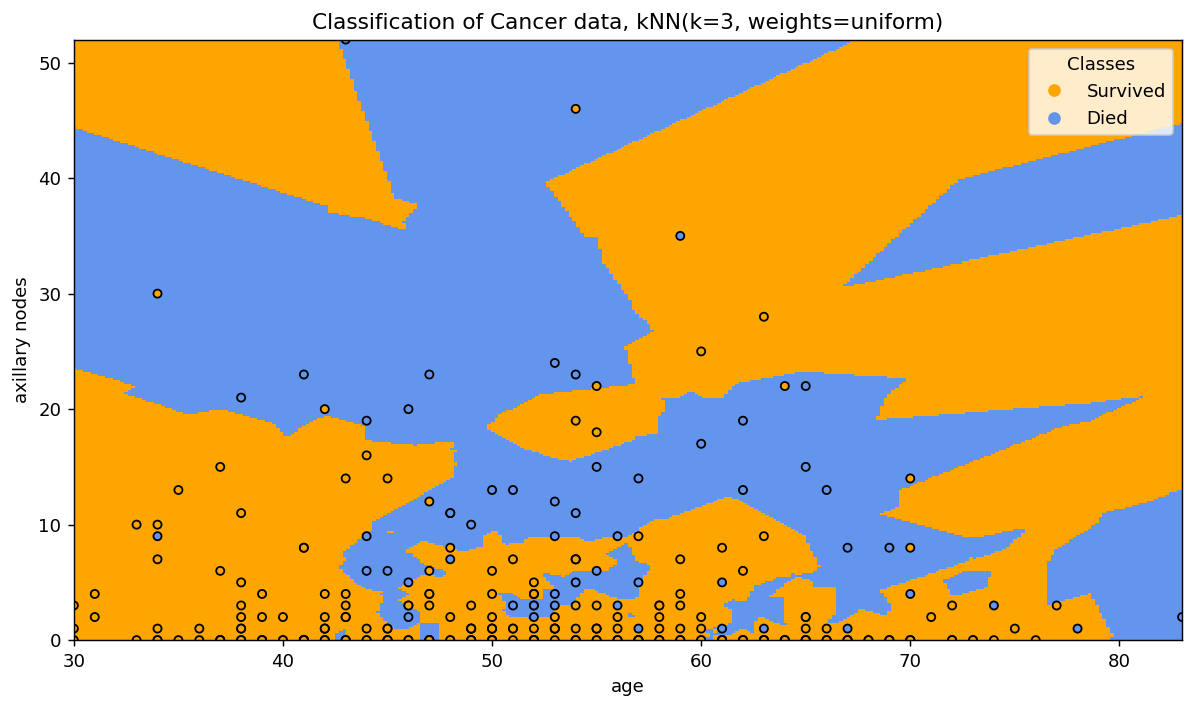


Mean accuracy for k=4 using (age, axillary nodes): 0.814


/Users/gdicaro/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


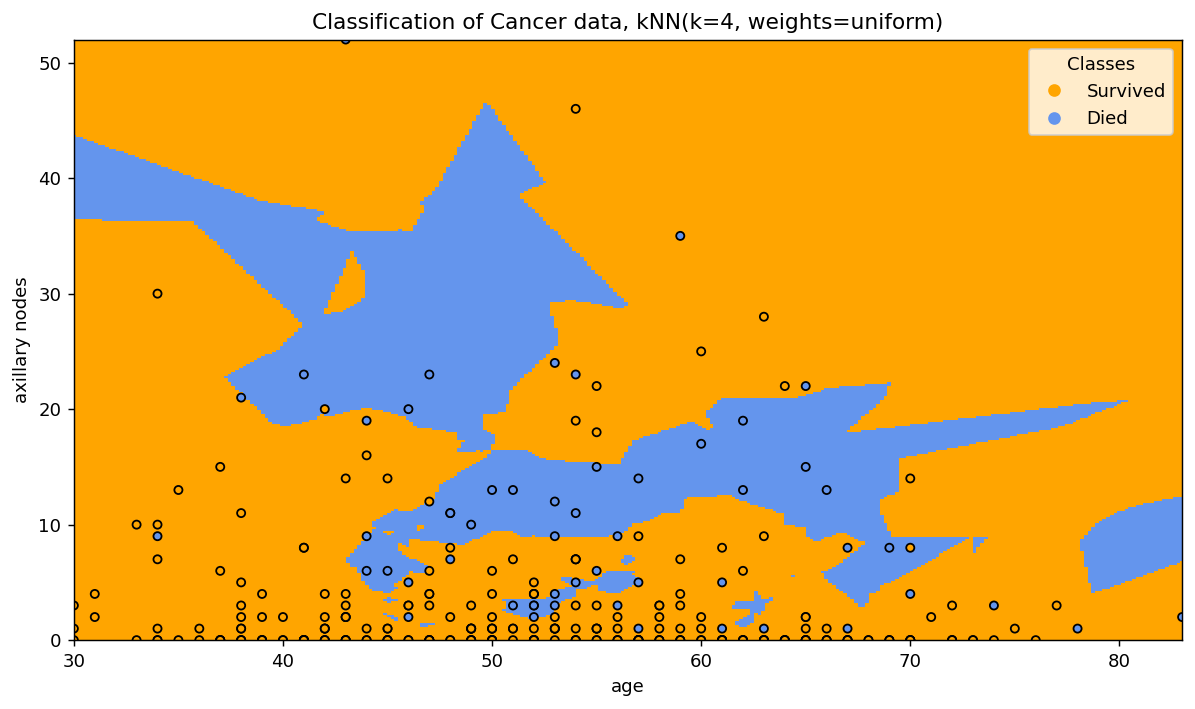


Mean accuracy for k=5 using (age, axillary nodes): 0.827


/Users/gdicaro/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


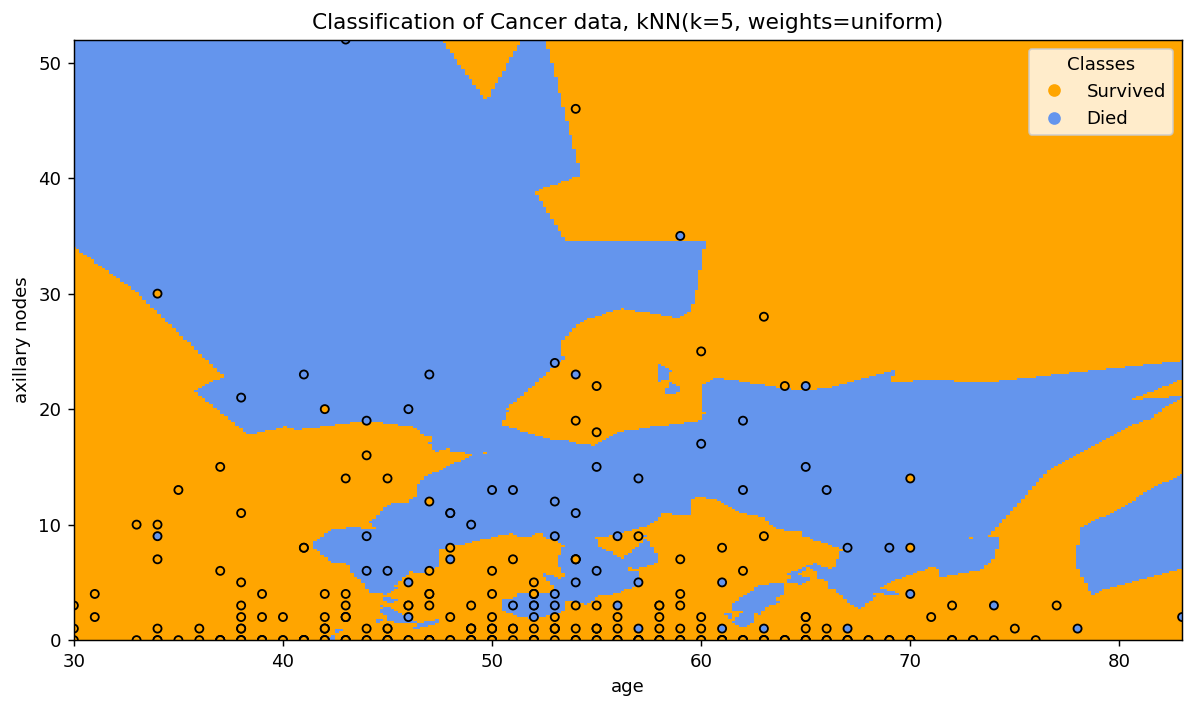


Mean accuracy for k=6 using (age, axillary nodes): 0.814


/Users/gdicaro/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


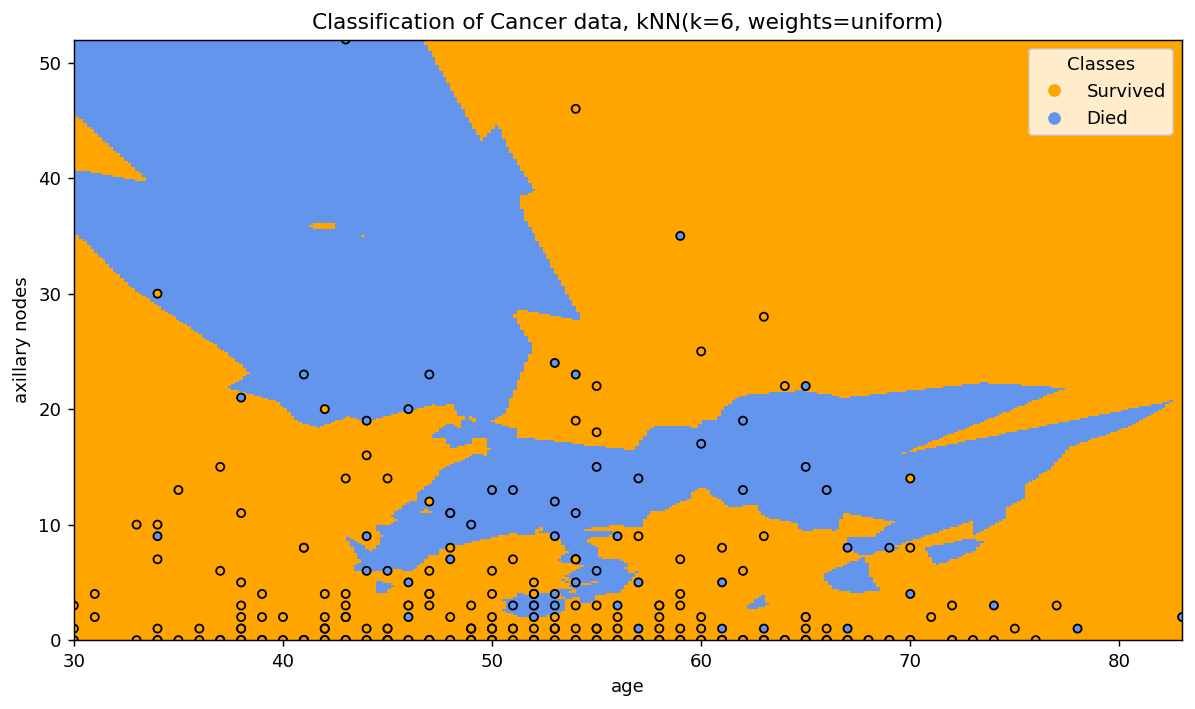


Mean accuracy for k=7 using (age, axillary nodes): 0.804


/Users/gdicaro/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


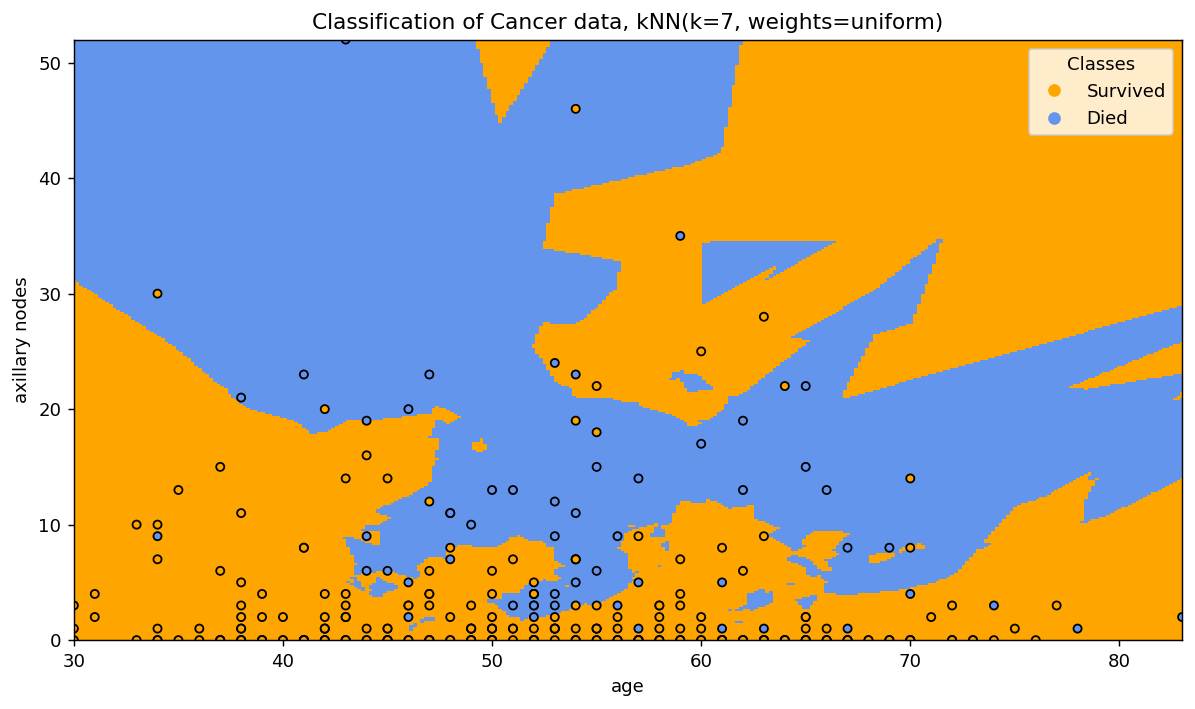


Mean accuracy for k=8 using (age, axillary nodes): 0.791


/Users/gdicaro/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


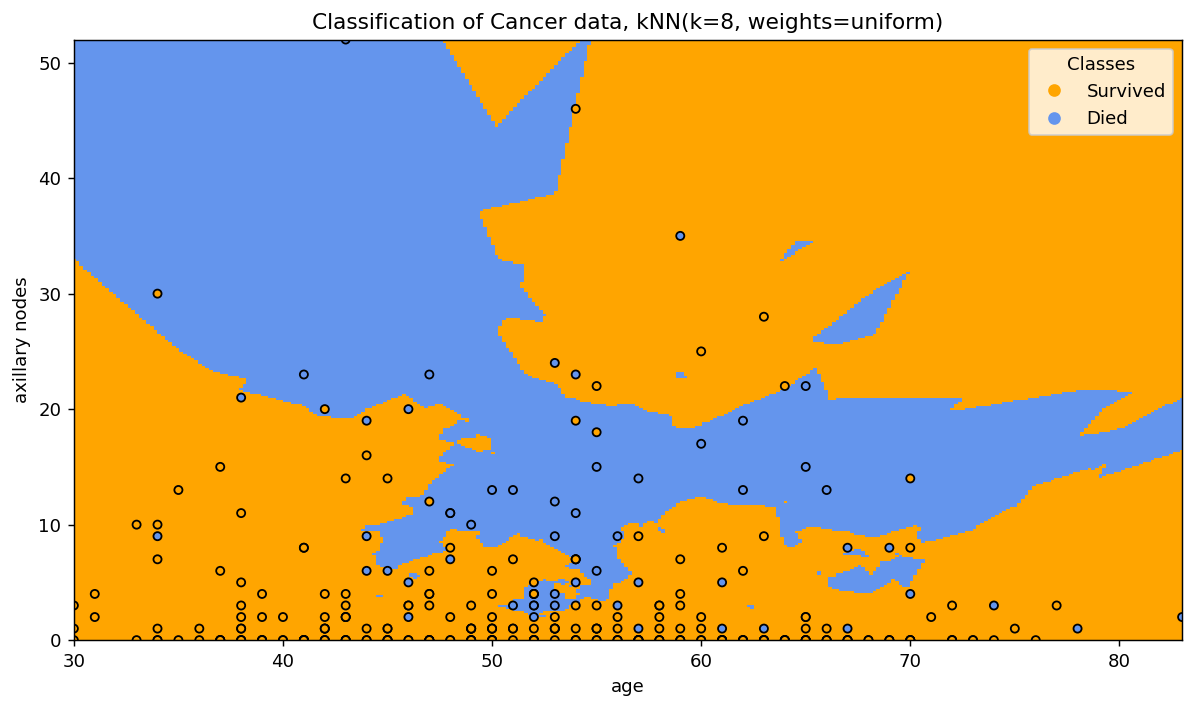


Mean accuracy for k=9 using (age, axillary nodes): 0.784


/Users/gdicaro/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


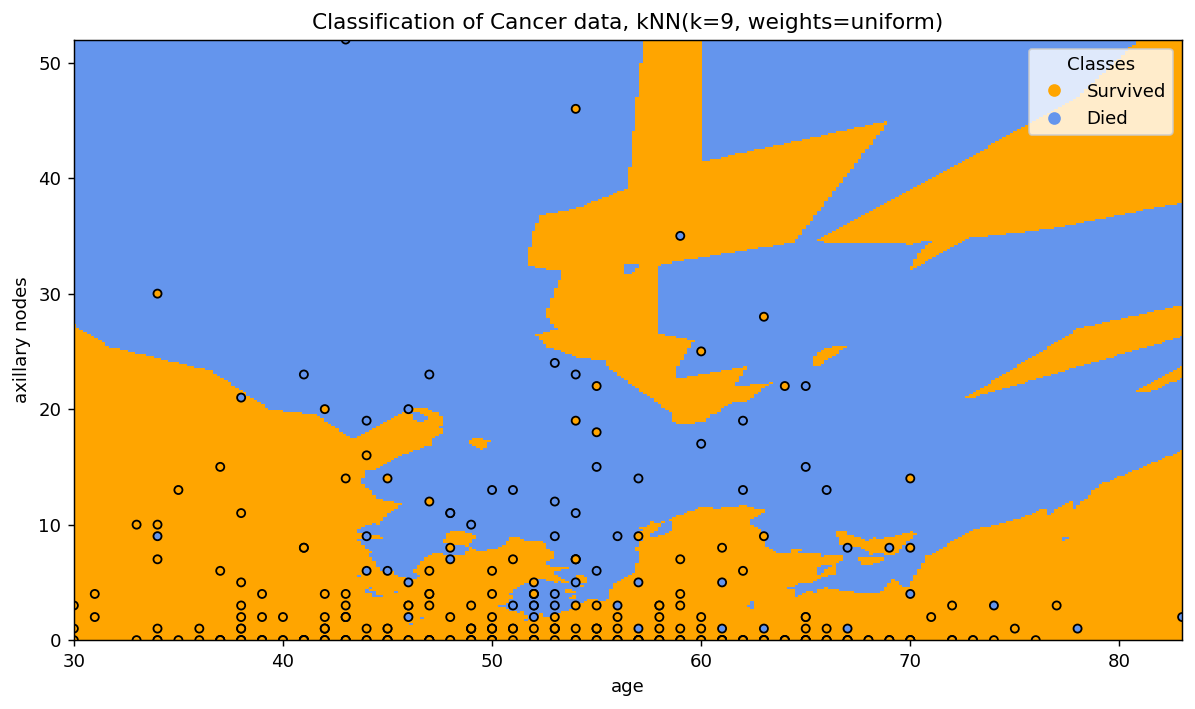


Mean accuracy for k=20 using (age, axillary nodes): 0.768


/Users/gdicaro/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


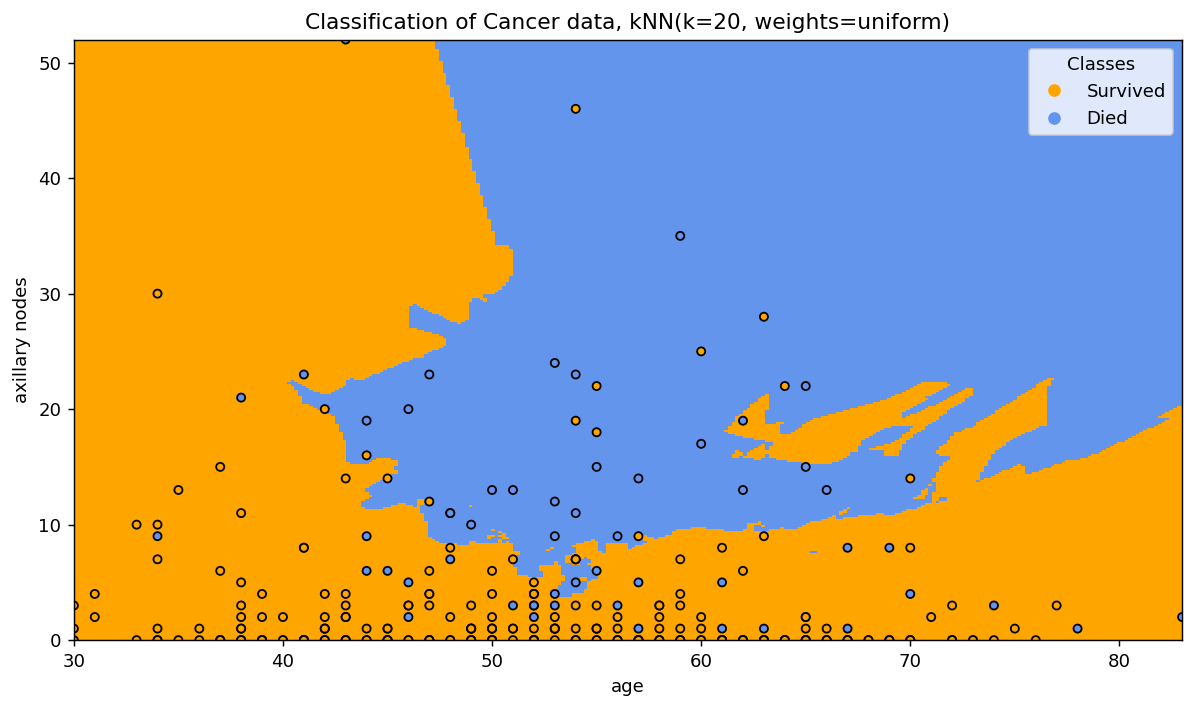


Mean accuracy for k=50 using (age, axillary nodes): 0.768


/Users/gdicaro/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


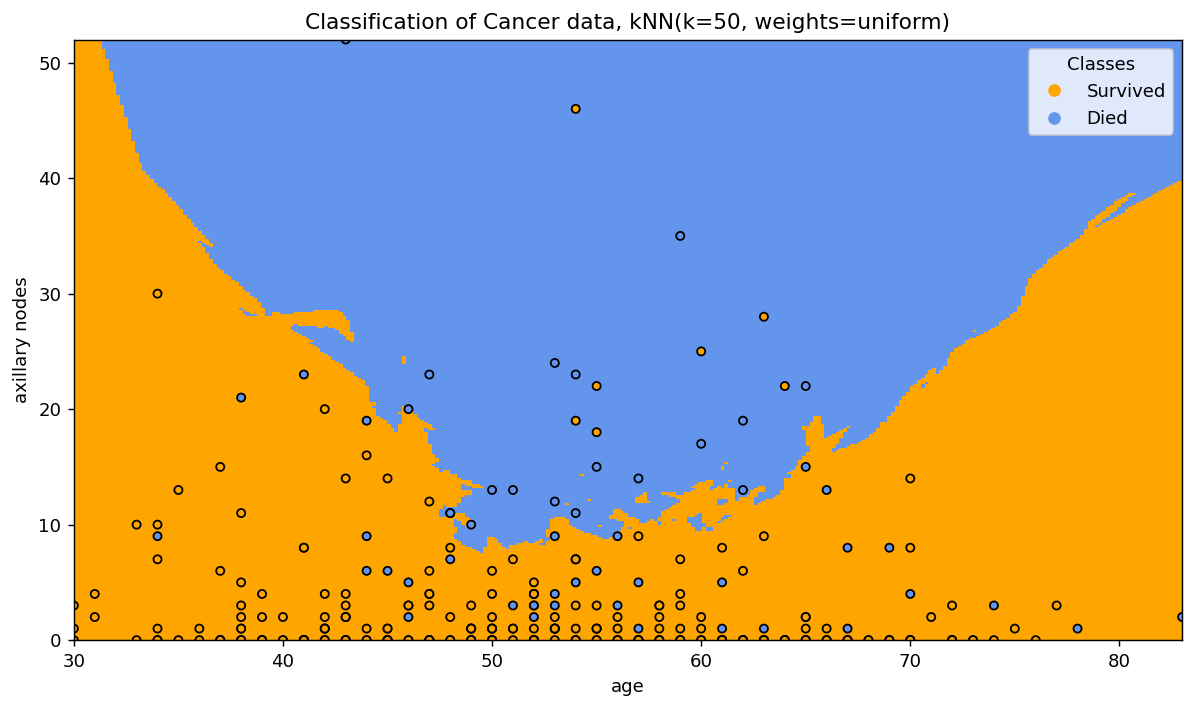

In [35]:
for k in list(range(1,10)) + [20] + [50]:

    classifier = learn_kNN_classifier(training_features_data, targets, 
                                      k, voting)

    predictions, accuracy = get_predictions(training_features_data, 
                                            targets, 
                                            classifier)

    print('\nMean accuracy for k={} using ({}, {}): {:.3f}'.format(k, 
                                                                   feature_names[0],
                                                                   feature_names[1],
                                                                   accuracy))

    title = 'Classification of Cancer data, kNN(k={}, weights={})'.format(k, voting)


    plot_decision_regions(training_features_data, targets,
                          classifier, 
                          legend_labels = ["Survived", "Died"],
                          meshgrid_pts = 300,
                          title=title, 
                          x1_name=feature_names[0], 
                          x2_name=feature_names[1], 
                          my_cmap=cmap_light, 
                          size=(11,6), data=True, s=20)


***
Questions (again!):<br><p>
    
 - How do we select the <font color='blue'> **best classifier?** </font><br><p>
 - Best combination of $k$ and voting procedure (counting, distances, which distance)<br><p>

- We are only measuring the **empirical error,** the performance on the training data!<br><p>    
    
- We are aiming to find the classifier with the best **generalization error**
    
- Fundamental problem of **(hyper)parameter setting** / **model selection**.    
    
🤔 ...
 
<div>
    <center>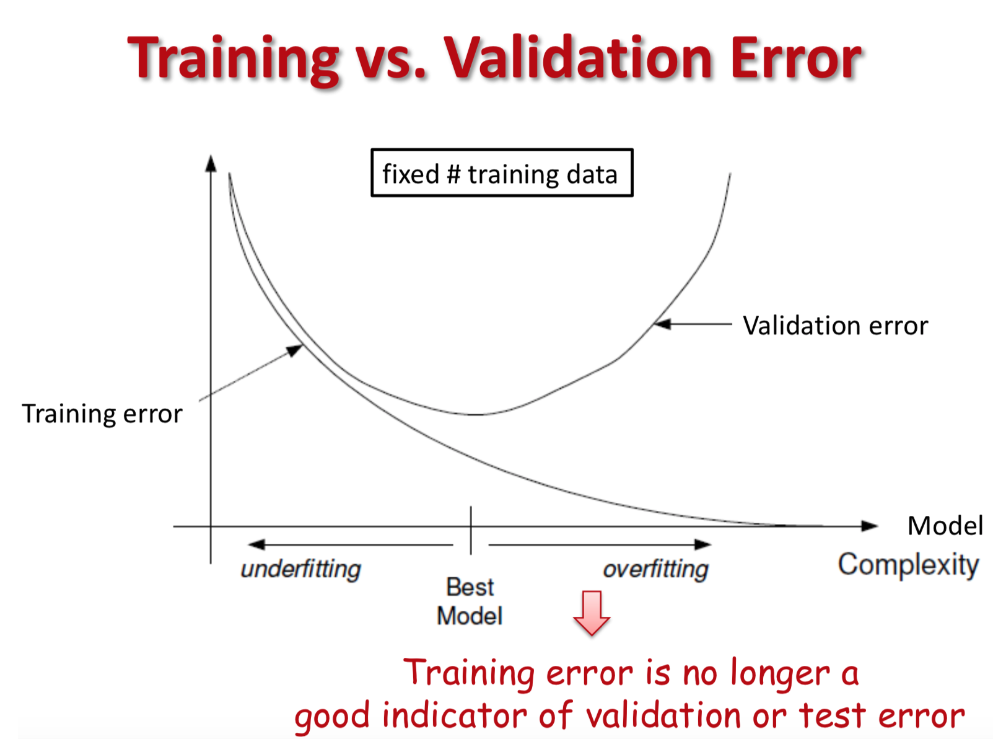</center>
</div>    
    
***

<u>Question:</u> On the **Model Complexity** axis how the $k$ values should be placed? i.e., Does a low $k$ correspond to large model complexity, or vice versa?

***
# <font color='red'>Model selection: use Hold-Out / Cross-Validation to select the **best model**</font>


- Let's apply <font color='red'>CV (K-Fold)</font> to select the *best* model (i.e., `k`) for the data.<br><p>

- First, let's considere the whole set of **3 features!** (in the plots above, we have considered only 2 features)

In [36]:
from sklearn.model_selection import cross_validate

features = cancer.iloc[:, 0:3]
labels = targets

k_fold = 30

k_vals = list(range(1,10)) + [20] + [25] + [30] + [50]

# list to store the results
all_cv_results = []

for k in k_vals:

    classifier = learn_kNN_classifier(features, 
                                      labels, 
                                      k, 
                                      'uniform')

    # if not specified either, K-Fold is the default CV method
    # and the cv argument specifies the number of foldings
    cv_results = cross_validate(classifier, features, labels, 
                                cv=k_fold,
                                return_train_score=True)
    
    print('[{:2d}-NN] Mean test score: {:.3f} (std: {:.3f})'
          '\n\tMean train score: {:.3f} (std: {:.3f})\n'.format(k,
                                                  np.mean(cv_results['test_score']),
                                                  np.std(cv_results['test_score']),
                                                  np.mean(cv_results['train_score']),
                                                  np.std(cv_results['train_score'])))
    all_cv_results.append(cv_results)

[ 1-NN] Mean test score: 0.656 (std: 0.117)
	Mean train score: 0.981 (std: 0.002)

[ 2-NN] Mean test score: 0.708 (std: 0.096)
	Mean train score: 0.834 (std: 0.006)

[ 3-NN] Mean test score: 0.682 (std: 0.123)
	Mean train score: 0.847 (std: 0.006)

[ 4-NN] Mean test score: 0.728 (std: 0.099)
	Mean train score: 0.805 (std: 0.006)

[ 5-NN] Mean test score: 0.715 (std: 0.126)
	Mean train score: 0.798 (std: 0.008)

[ 6-NN] Mean test score: 0.725 (std: 0.090)
	Mean train score: 0.790 (std: 0.005)

[ 7-NN] Mean test score: 0.709 (std: 0.115)
	Mean train score: 0.763 (std: 0.007)

[ 8-NN] Mean test score: 0.729 (std: 0.099)
	Mean train score: 0.763 (std: 0.005)

[ 9-NN] Mean test score: 0.719 (std: 0.141)
	Mean train score: 0.770 (std: 0.006)

[20-NN] Mean test score: 0.755 (std: 0.084)
	Mean train score: 0.761 (std: 0.006)

[25-NN] Mean test score: 0.762 (std: 0.097)
	Mean train score: 0.756 (std: 0.005)

[30-NN] Mean test score: 0.758 (std: 0.101)
	Mean train score: 0.768 (std: 0.006)

[50-

***

Remember that the object returned from `cross_validate` is a dictionary with a lot of data about the cv process. This shows for the last `k` case

In [37]:
np.set_printoptions(precision=3)
cv_results

{'fit_time': array([0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001,
        0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001,
        0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001,
        0.001, 0.001, 0.001]),
 'score_time': array([0.002, 0.001, 0.002, 0.002, 0.002, 0.002, 0.001, 0.001, 0.001,
        0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.002, 0.001, 0.002,
        0.002, 0.002, 0.002, 0.001, 0.002, 0.002, 0.002, 0.001, 0.001,
        0.001, 0.001, 0.001]),
 'test_score': array([0.727, 0.727, 0.727, 0.818, 0.727, 0.727, 0.8  , 0.8  , 1.   ,
        0.8  , 0.8  , 0.8  , 0.9  , 0.9  , 0.8  , 0.6  , 0.6  , 0.7  ,
        0.8  , 0.8  , 0.7  , 0.8  , 0.8  , 0.7  , 0.6  , 0.8  , 0.7  ,
        0.7  , 0.7  , 0.7  ]),
 'train_score': array([0.756, 0.759, 0.759, 0.756, 0.756, 0.759, 0.757, 0.76 , 0.753,
        0.76 , 0.76 , 0.76 , 0.757, 0.757, 0.757, 0.767, 0.767, 0.757,
        0.753, 0.75 , 0.757, 0.757, 0.757, 0.757, 0.76 , 0.753, 0.757,


***
Let's plot the results!

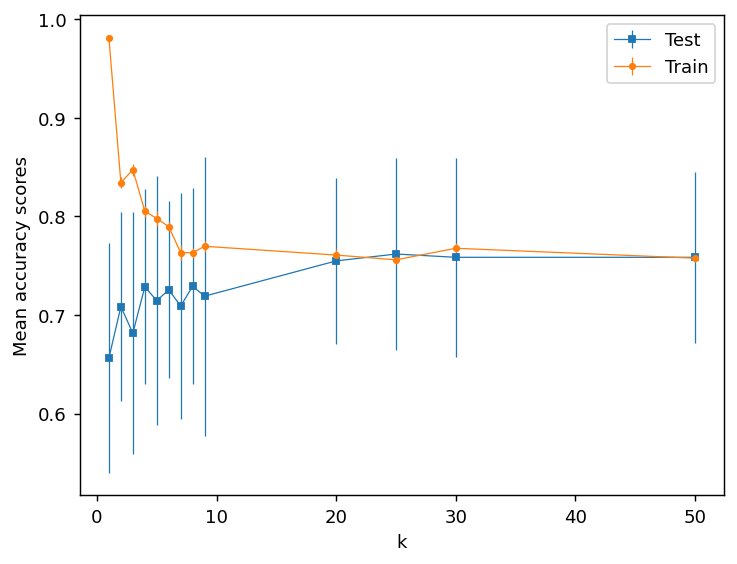

In [38]:
plt.figure()
plt.xlabel('k')
plt.ylabel('Mean accuracy scores')

all_train_mean = []
all_test_mean = []
all_train_std = []
all_test_std = []
for exp in all_cv_results:
    all_train_mean.append(np.mean(exp['train_score']))
    all_test_mean.append(np.mean(exp['test_score']))
    
    all_train_std.append(np.std(exp['train_score']))
    all_test_std.append(np.std(exp['test_score']))
            
plt.errorbar(k_vals, all_test_mean, yerr=all_test_std, 
             marker='s', markersize='3', linewidth=0.7, label='Test')

plt.errorbar(k_vals, all_train_mean, yerr=all_train_std, 
             marker='o', markersize='3', linewidth=0.7, label='Train')

plt.legend()
plt.show()

***
**Which model do you select?**

***
# <font color='red'>Automatic grid search for model selection (i.e., best $k$)</font>

Let's use `GridSearchCV()` to automate the search process for the best $k$.

First, we consider the whole set of 3 features. 


In [39]:
from sklearn.model_selection import GridSearchCV

# generic k-NN, with set weight but unset k 
classifier = KNeighborsClassifier(weights='uniform')

# estimator object that will perform a grid search over the
# set of the given hyperparameters
parameters_grid = {'n_neighbors': k_vals }
    
estimator = GridSearchCV(classifier, parameters_grid)
    
# fit the estimator to the training data
estimator.fit(features, labels)

print('Best accuracy score: {:.3f}'.format(estimator.best_score_))

print('Best estimator: {}'.format(estimator.best_estimator_))

print('\nBest k neighbors: {}'.format(estimator.best_params_['n_neighbors']))


Best accuracy score: 0.771
Best estimator: KNeighborsClassifier(n_neighbors=30)

Best k neighbors: 30


***
- Let's apply the method for the data by considering this time only **two features!**

In [40]:
# let's use the two 'meaningful' features 
feature_x = 0
feature_y = 2
selected_feature_data = cancer.iloc[:, [feature_x, feature_y]]

In [41]:
# generic k-NN, with set weight but unset k 
classifier = KNeighborsClassifier(weights='uniform')

# estimator object that will perform a grid search over the
# set of the given hyperparameters
parameters_grid = {'n_neighbors': k_vals }
    
estimator = GridSearchCV(classifier, parameters_grid)
    
# fit the estimator to the training data
estimator.fit(selected_feature_data, labels)

print('Best accuracy score: {:.3f}'.format(estimator.best_score_))

print('Best estimator: {}'.format(estimator.best_estimator_))

print('\nBest k neighbors: {}'.format(estimator.best_params_['n_neighbors']))


Best accuracy score: 0.775
Best estimator: KNeighborsClassifier(n_neighbors=25)

Best k neighbors: 25


***
# <font color='red'>k-NN and role of distances</font>

So far we have only considered $k$ as relevant hyper-parameter of the algorithm. Let's now give also a look at the **distance** parameters.

In [42]:
#help(classifier)

***
## <font color='red'>Minkowski distance?</font>

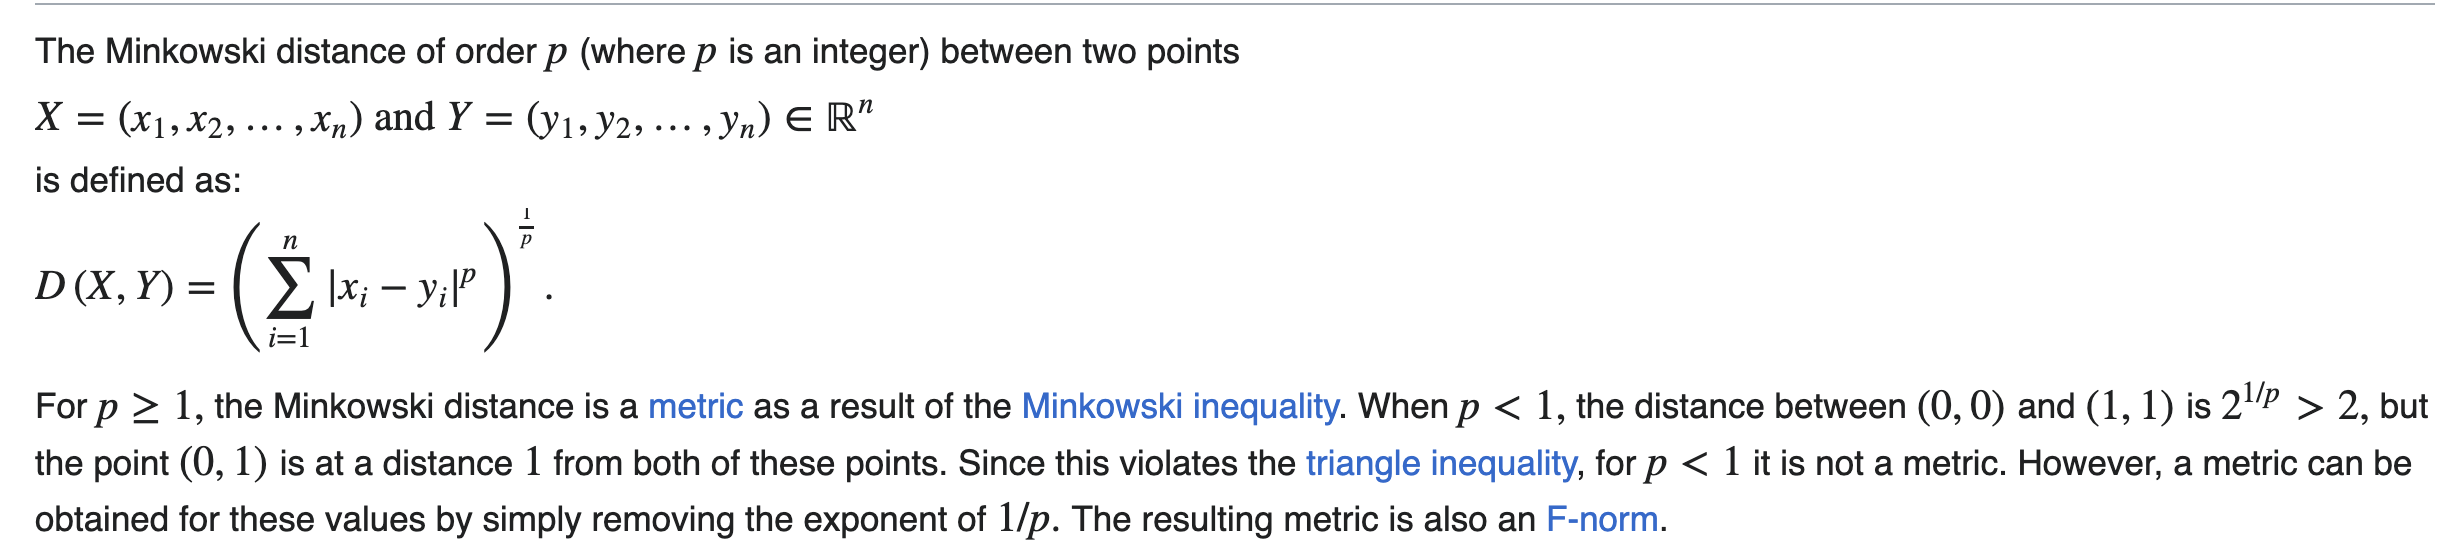

***
## <font color='red'>$L_p$-norm and distances</font>

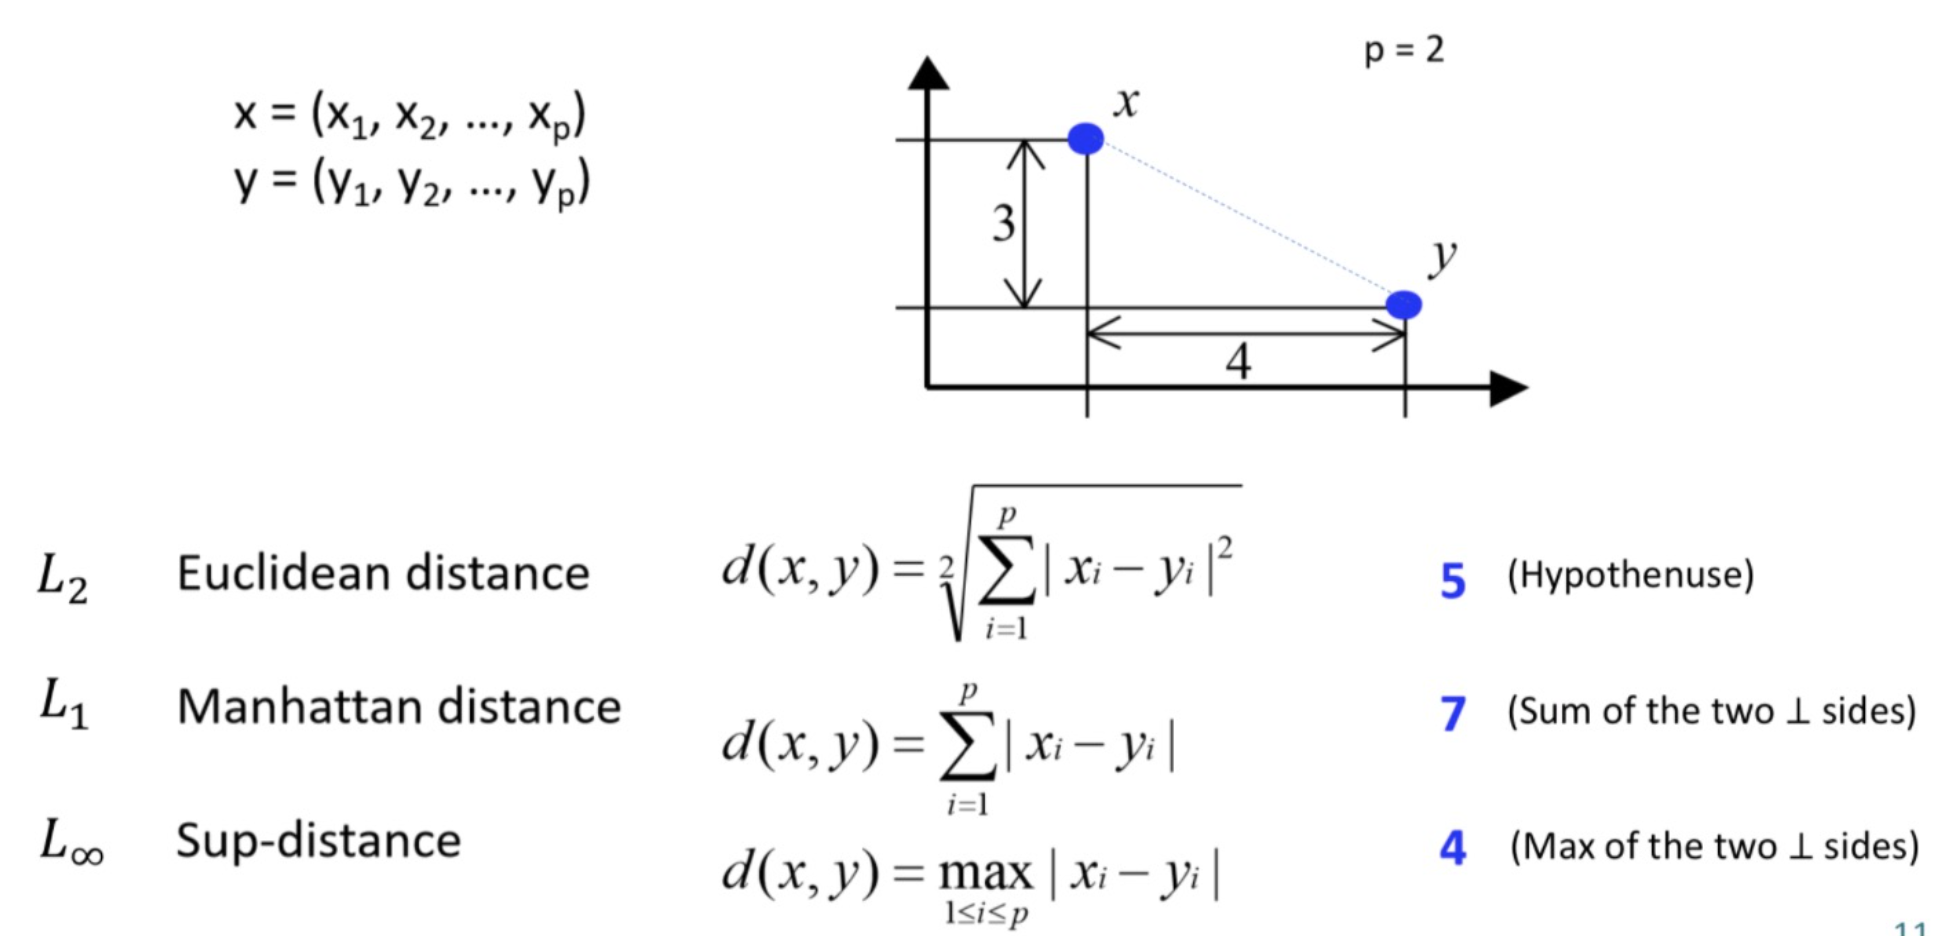

***

Unit sets: the **level set of the distance function where all points are at the unit distance from the center**

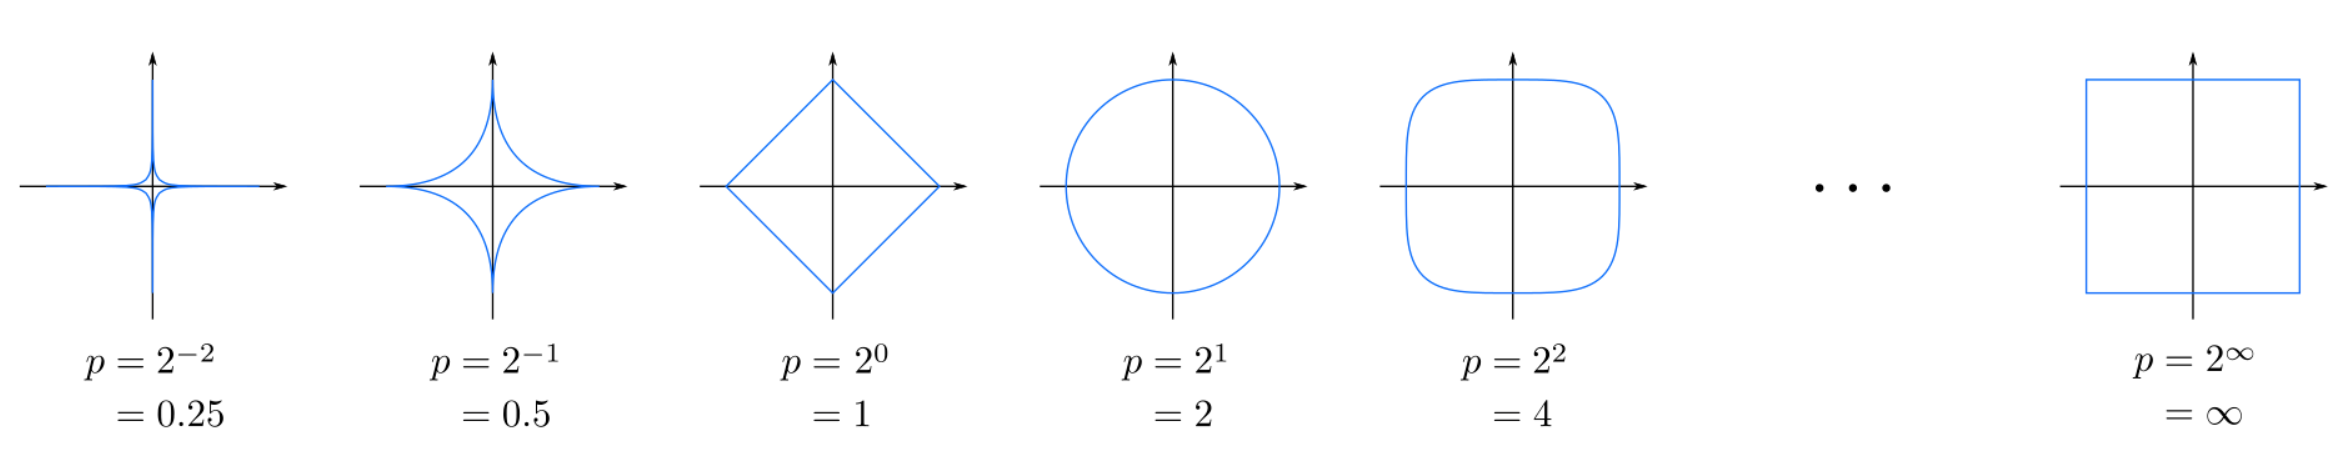


***
Let's see if results change by changing the way of voting

In [43]:
# generic k-NN, with set weight but unset k 
classifier = KNeighborsClassifier(weights='distance', p=1)

# estimator object that will perform a grid search over the
# set of the given hyperparameters
parameters_grid = {'n_neighbors': k_vals }
    
estimator = GridSearchCV(classifier, parameters_grid)
    
# fit the estimator to the training data
estimator.fit(selected_feature_data, labels)

print('Best accuracy score: {:.3f}'.format(estimator.best_score_))

print('Best estimator: {}'.format(estimator.best_estimator_))

print('\nBest k neighbors: {}'.format(estimator.best_params_['n_neighbors']))


Best accuracy score: 0.716
Best estimator: KNeighborsClassifier(n_neighbors=30, p=1, weights='distance')

Best k neighbors: 30


***
Let's look at the **Iris dataset** again, considering only two features and considering also weight and distance metric has parameters!

In [44]:
from sklearn.datasets import load_iris
iris = load_iris()

feature_x = 0
feature_y = 1

# matrix 
X = iris.data[:, [feature_x, feature_y]]
Y = iris.target

In [45]:
# generic k-NN, with set weight but unset k 
classifier = KNeighborsClassifier()

# estimator object that will perform a grid search over the
# set of the given hyperparameters
parameters_grid = {'n_neighbors': k_vals, 'weights': ['uniform', 'distance'],
                  'p':[1, 2, 3, 10]}
    
estimator = GridSearchCV(classifier, parameters_grid)
    
# fit the estimator to the training data
estimator.fit(X, Y)

print('Best accuracy score: {:.3f}'.format(estimator.best_score_))

print('Best estimator: {}'.format(estimator.best_estimator_))

print('\nBest params: {}'.format(estimator.best_params_))


Best accuracy score: 0.813
Best estimator: KNeighborsClassifier(n_neighbors=25)

Best params: {'n_neighbors': 25, 'p': 2, 'weights': 'uniform'}


***
What about changing the features?


In [46]:
feature_x = 1
feature_y = 3

# matrix 
X = iris.data[:, [feature_x, feature_y]]
Y = iris.target

In [47]:
# generic k-NN, with set weight but unset k 
classifier = KNeighborsClassifier()

# estimator object that will perform a grid search over the
# set of the given hyperparameters
parameters_grid = {'n_neighbors': k_vals, 'weights': ['uniform', 'distance'],
                  'p':[1, 2, 3, 10]}
    
estimator = GridSearchCV(classifier, parameters_grid)
    
# fit the estimator to the training data
estimator.fit(X, Y)

print('Best accuracy score: {:.3f}'.format(estimator.best_score_))

print('Best estimator: {}'.format(estimator.best_estimator_))

print('\nBest params: {}'.format(estimator.best_params_))


Best accuracy score: 0.967
Best estimator: KNeighborsClassifier(n_neighbors=6, p=1)

Best params: {'n_neighbors': 6, 'p': 1, 'weights': 'uniform'}


***
With all four features

In [48]:
X = iris.data[:, 0:4]
Y = iris.target

In [49]:
# generic k-NN, with set weight but unset k 
classifier = KNeighborsClassifier()

# estimator object that will perform a grid search over the
# set of the given hyperparameters
parameters_grid = {'n_neighbors': k_vals, 'weights': ['uniform', 'distance'],
                  'p':[1, 2, 3, 10]}
    
estimator = GridSearchCV(classifier, parameters_grid)
    
# fit the estimator to the training data
estimator.fit(X, Y)

print('Best accuracy score: {:.3f}'.format(estimator.best_score_))

print('Best estimator: {}'.format(estimator.best_estimator_))

print('\nBest params: {}'.format(estimator.best_params_))


Best accuracy score: 0.987
Best estimator: KNeighborsClassifier(n_neighbors=6, p=3)

Best params: {'n_neighbors': 6, 'p': 3, 'weights': 'uniform'}


***
# <font color='red'>Measures of performance for classification: Accuracy, Recall, Precision, F1, Confusion Matrix</font>

So far, in classification, we have used the 0/1 loss, computed mean classification accuracy, and we have used it as a measure of performance

***
<font color='blue'>**Mean classification error using the 0/1 Loss:**</font>

$$\bar{E} = \frac{1}{m}\sum_{all\ data} {\bf 1}_{clf(x,t) \ne  t}$$

Count and average all classification errors

<font color='red'>$$Mean Accuracy\ = 1 - \bar{E}$$ </font>

... however, accuracy might be not telling the real 'truth' about our classifier ...

***
For a **binary** classification task, `+` and `-` labels
<div>
    <center>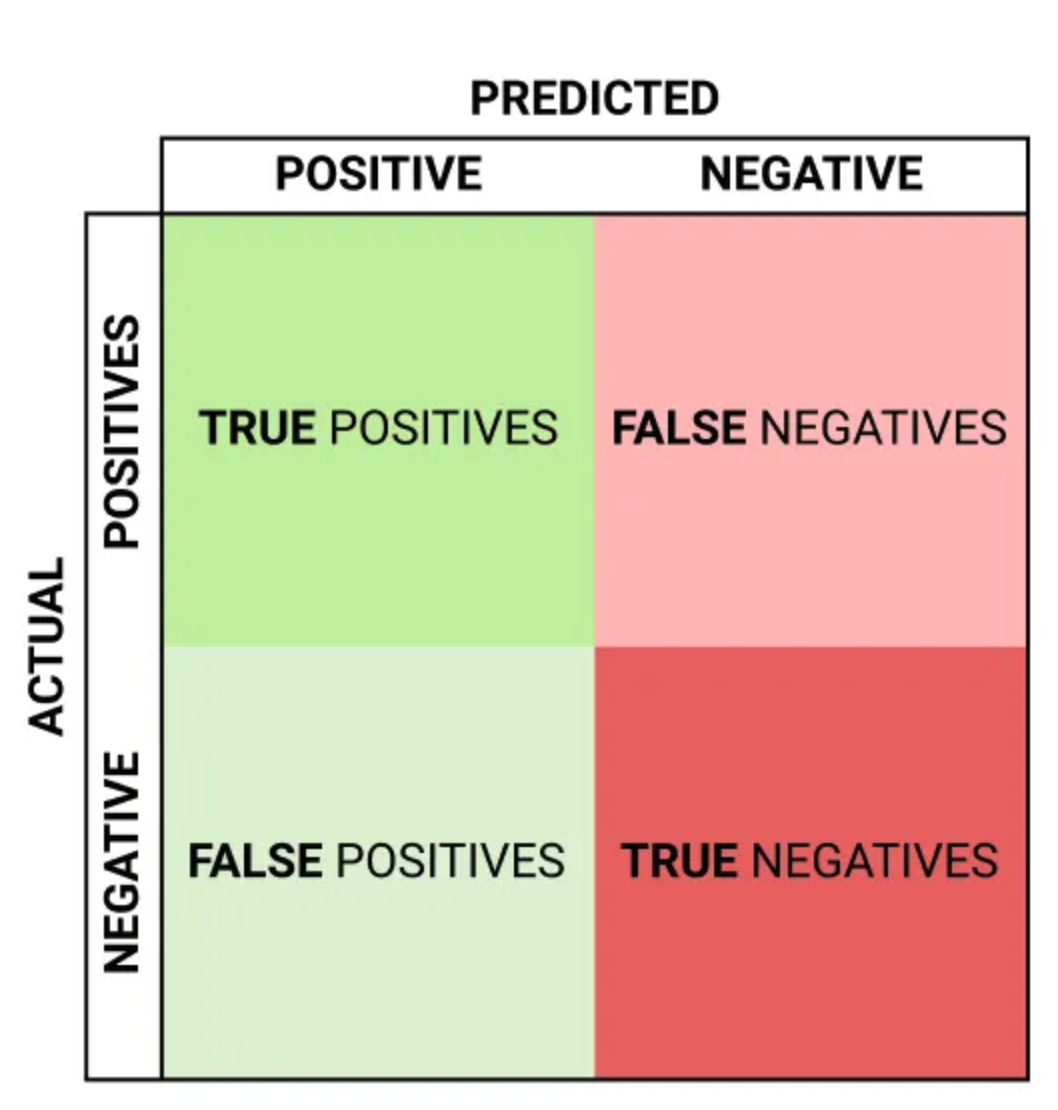</center>
</div>


$$Recall^+ = \frac{TP}{TP + FN}$$

$$Precision^+ = \frac{TP}{TP + FP}$$ 

***
- $\color{blue}{Recall}$: Look at the *Positives* row of the matrix (the actual positives):
    - High <font color='blue' ><b>Recall</b> </font> means that <u>positive class is classified well</u>, there are a very few False Negative cases (FN $\approx 0$).<br><p>

***
    
- $\color{blue}{Precision}$: Look at the *Positives* column of the matrix (the predicted positives):
    - High <font color='blue' ><b>Precision</b> </font> means that <u>examples predicted as positive are indeed positive</u>. There are only very few False Positive cases (FP $\approx 0$).

***
**Example:** We want to test a population sample of $m$ individuals for finding a rare disease. An individual is labeled $\color{red}{\large +}$ if he/she has the disease, $\color{green}{\large -}$ otherwise. 

To perform the test, we have trained a classifier over a dataset with $n=1000$ labeled examples, where **990** examples are $\color{green}{\large -}$ , and **10** examples are $\color{red}{\large +}$. 

- Accuracy of classifier on the training dataset is 98% (and CV more or less confirms this accuracy)

Are we happy with the result, such that we can start using it?

It depends ... Let's consider two extreme scenarios:

1. If the 20 wrongly predicted samples include 9 of the 10 +ve examples, the classifier is really bad, it can't be used to spot the rare disease!!!<br><p>

1. If the 20 wrongly predicted samples do not include any of the +ve examples, the result is definitely good!

- In scenario 1, 9 +ve examples were classified as negative, and 11 -ve examples were classified as +ve, only 1 +ve example was correctly classified as +ve:

  $$Recall = \frac{1}{1+9} = 0.1$$   
  $$Precision = \frac{1}{1+11} = 0.08$$   

- In scenario 2, 20 -ve examples were classified as +ve, and the 10 +ve examples were correctly classified as +ve:

  $$Recall = \frac{10}{10+0} = 1$$   
  $$Precision = \frac{10}{10+20} = 0.33$$   

$\to$ In both cases, accuracy was 0.98, but it was not telling the true story about the classifier!

***
For a **multi-class classifier**, the same measures can be computed considering each individual class vs. all the other classes (i.e., reducing the problem to a set of binary classification problems)
***

Let's check it out with the cancer dataset (binary)

In [50]:
X = cancer.iloc[:, [0,2]]
Y = cancer.iloc[:, -1]

# generic k-NN, with set weight but unset k 
classifier = KNeighborsClassifier()

# estimator object that will perform a grid search over the
# set of the given hyperparameters
parameters_grid = {'n_neighbors': k_vals, 'weights': ['uniform', 'distance'],
                  'p':[1, 2, 3, 10]}
    
estimator = GridSearchCV(classifier, parameters_grid, 
                         cv=10, # cv specifies the number k of folds
                         return_train_score=True)  # this is to get all training data
    
# fit the estimator to the training data
estimator.fit(X, Y)

print('Best accuracy score: {:.3f}'.format(estimator.best_score_))

print('Best estimator: {}'.format(estimator.best_estimator_))

print('\nBest params: {}'.format(estimator.best_params_))

Best accuracy score: 0.774
Best estimator: KNeighborsClassifier(n_neighbors=30)

Best params: {'n_neighbors': 30, 'p': 2, 'weights': 'uniform'}


In [51]:
estimator.cv_results_['mean_train_score']

array([0.845, 0.845, 0.845, 0.845, 0.845, 0.845, 0.845, 0.845, 0.839,
       0.91 , 0.84 , 0.91 , 0.84 , 0.91 , 0.84 , 0.91 , 0.835, 0.909,
       0.832, 0.909, 0.832, 0.909, 0.832, 0.909, 0.818, 0.915, 0.814,
       0.915, 0.814, 0.915, 0.814, 0.915, 0.818, 0.915, 0.824, 0.915,
       0.818, 0.915, 0.822, 0.915, 0.803, 0.915, 0.806, 0.915, 0.802,
       0.915, 0.802, 0.915, 0.808, 0.915, 0.805, 0.915, 0.801, 0.915,
       0.802, 0.915, 0.793, 0.915, 0.79 , 0.915, 0.785, 0.915, 0.79 ,
       0.915, 0.805, 0.915, 0.781, 0.915, 0.788, 0.915, 0.791, 0.915,
       0.765, 0.915, 0.769, 0.915, 0.778, 0.915, 0.778, 0.915, 0.761,
       0.915, 0.761, 0.915, 0.768, 0.915, 0.768, 0.915, 0.756, 0.915,
       0.763, 0.915, 0.766, 0.915, 0.767, 0.915, 0.742, 0.915, 0.758,
       0.915, 0.76 , 0.915, 0.757, 0.915])

In [52]:
estimator.cv_results_['mean_test_score']

array([0.668, 0.668, 0.665, 0.665, 0.665, 0.665, 0.665, 0.665, 0.671,
       0.671, 0.668, 0.661, 0.668, 0.661, 0.668, 0.661, 0.665, 0.658,
       0.662, 0.658, 0.665, 0.658, 0.665, 0.658, 0.703, 0.665, 0.687,
       0.655, 0.687, 0.652, 0.687, 0.652, 0.697, 0.652, 0.704, 0.662,
       0.704, 0.662, 0.704, 0.655, 0.719, 0.662, 0.716, 0.658, 0.713,
       0.649, 0.72 , 0.649, 0.69 , 0.652, 0.697, 0.658, 0.703, 0.662,
       0.694, 0.662, 0.723, 0.652, 0.723, 0.672, 0.723, 0.658, 0.726,
       0.662, 0.732, 0.668, 0.726, 0.675, 0.72 , 0.671, 0.719, 0.678,
       0.749, 0.678, 0.752, 0.674, 0.765, 0.674, 0.765, 0.681, 0.749,
       0.687, 0.758, 0.694, 0.761, 0.697, 0.758, 0.697, 0.752, 0.69 ,
       0.774, 0.71 , 0.774, 0.717, 0.765, 0.703, 0.732, 0.69 , 0.752,
       0.71 , 0.771, 0.71 , 0.761, 0.713])

In [53]:
Y_pred = estimator.predict(X)
Y_test = Y

In [54]:
# Model Precision: what percentage of positive tuples are labeled as such?
print('Precision (+ve examples are actually the positive ones): {:.3f}'.format(metrics.precision_score(Y_test, Y_pred)))

# Model Recall: what percentage of positive tuples are labelled as such?
print('Recall (+ve examples are classified correctly): {:.3f}'.format(metrics.recall_score(Y_test, Y_pred)))

Precision (+ve examples are actually the positive ones): 0.779
Recall (+ve examples are classified correctly): 0.942


***
## <font color='red'>Full report on classification performance and F1 metric</font>

`classification_report` provides a full report on performance where `f1` is a measure that combines precision and recall

- <font color='blue'>**F1-score**:</font> weighted harmonic mean of precision and recall, 
    - F1 score == 1: Excellent accuracy, recall, and precision!
    - F1 score == 0: Really bad! 
     

F1-score is a special case of the F$\beta$-score, where we can weight recall vs. precision by a factor $\beta$.<br> For F1, $\beta = 1.0$, that means recall and precision are equally important.
   
<font color='blue'>$$\text{F1} = \frac{2 (Precision \cdot Recall)}{Precision + Recall}$$</font>

In [55]:
print(metrics.classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           1       0.78      0.94      0.85       225
           2       0.62      0.26      0.37        81

    accuracy                           0.76       306
   macro avg       0.70      0.60      0.61       306
weighted avg       0.74      0.76      0.72       306



- The `support` is the number of occurrences of each class for the true labels

***
## <font color='red' ><b>Confusion matrix</b>  (to check cross-missclassifications)</font>

A confusion matrix summarizes the number of predictions made by a model for each class, and the classes to which those predictions actually belong. It helps to understand the types of prediction errors made by a model.

In [56]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def show_confusion_matrix(true_labels, predicted_labels, class_names):

    cmat = confusion_matrix(true_labels, predicted_labels) 

    plt.figure(figsize=(14, 5))

    plt.tick_params(labelsize=8)

    
    hm = sns.heatmap(cmat.T, square=True, annot=True, fmt='d', cbar=True,
                     xticklabels=class_names,
                     yticklabels=class_names, 
                     cmap="seismic", 
                     annot_kws={"size":12}, cbar_kws={'label': 'Counts'})

    # this is to set the last axis of the figure, the colorbar in this case
    hm.figure.axes[-1].yaxis.label.set_size(10) # fontsize of bar label
    hm.figure.axes[-1].tick_params(labelsize=8) # fontsize of ticks labels
    
    #plt.ylim(10, 0)

    plt.xlabel('True label', fontsize=9)
    plt.ylabel('Predicted label', fontsize=9)
    
    plt.show()
    

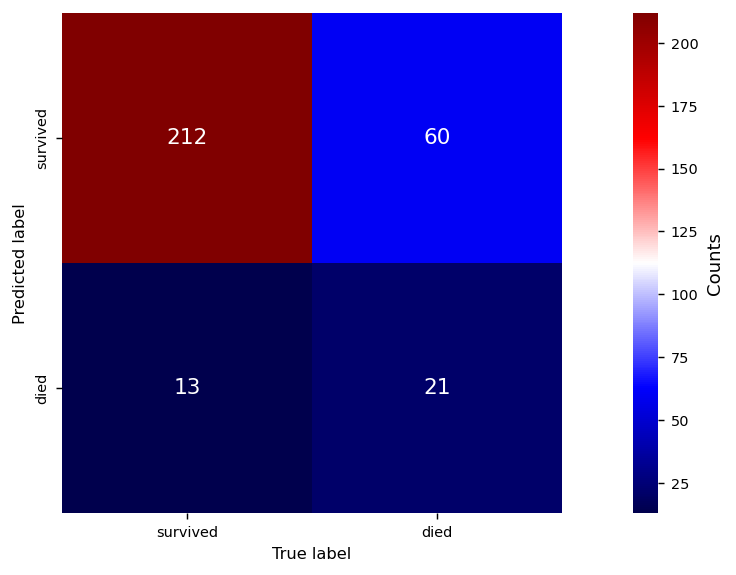

In [57]:
show_confusion_matrix(Y_test, Y_pred, ['survived', 'died'])

***
Do it yourself for the Iris data!